In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("PISA_2022_WithMeanScore.csv")  # change file name

In [3]:
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(613744, 223)
   CNT  CNTRYID  CNTSCHID  CNTSTUID STRATUM  REGION  OECD  ST001D01T  \
0  ALB      8.0  800282.0  800001.0   ALB03   800.0   0.0       10.0   
1  ALB      8.0  800115.0  800002.0   ALB03   800.0   0.0        9.0   
2  ALB      8.0  800242.0  800003.0   ALB01   800.0   0.0        9.0   
3  ALB      8.0  800245.0  800005.0   ALB08   800.0   0.0        8.0   
4  ALB      8.0  800285.0  800006.0   ALB03   800.0   0.0       10.0   

   ST003D03T  ST004D01T  ...  PV4SCIE  PV5SCIE  PV6SCIE  PV7SCIE  PV8SCIE  \
0     2006.0        1.0  ...  263.027  263.343  308.478  309.256  273.810   
1     2006.0        2.0  ...  270.154  348.569  320.866  275.114  319.327   
2     2006.0        2.0  ...  328.270  309.492  333.690  339.446  290.172   
3     2006.0        1.0  ...  163.129  280.386  229.360  197.635  199.556   
4     2006.0        1.0  ...  508.182  472.252  425.544  489.097  489.592   

   PV9SCIE  PV10SCIE  Math_MeanScore  Reading_MeanScore  Science_MeanScore  
0  297.433   

In [4]:
print(df.isnull().sum().sort_values(ascending=False))

CURSUPP              552501
CREATACT             543762
PQMCAR               525762
PASCHPOL             523936
CREATHME             523865
                      ...  
PV9SCIE                   0
PV10SCIE                  0
Math_MeanScore            0
Reading_MeanScore         0
Science_MeanScore         0
Length: 223, dtype: int64


In [5]:
df_eda = df[[
    "CNT",        # country
    "ST004D01T",  # gender
    "PV1MATH",
    "PV1READ",
    "PV1SCIE",
    "ESCS"
]].copy()

In [6]:
df_eda = df_eda.dropna(subset=["PV1MATH", "PV1READ", "PV1SCIE"])

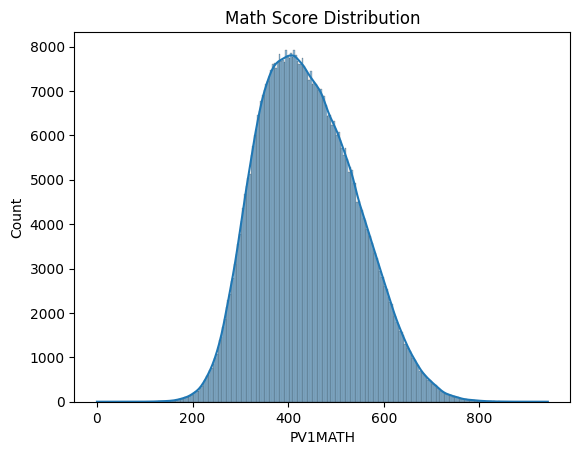

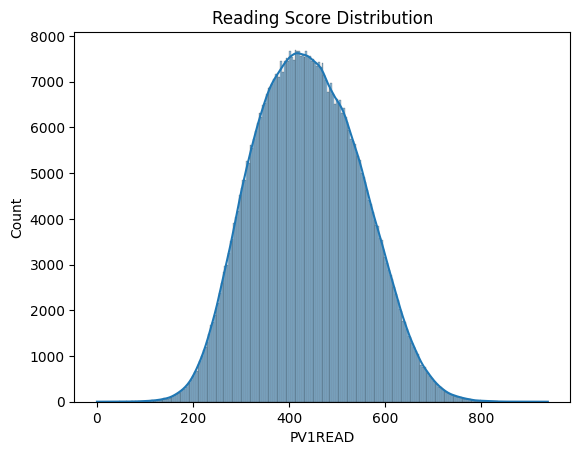

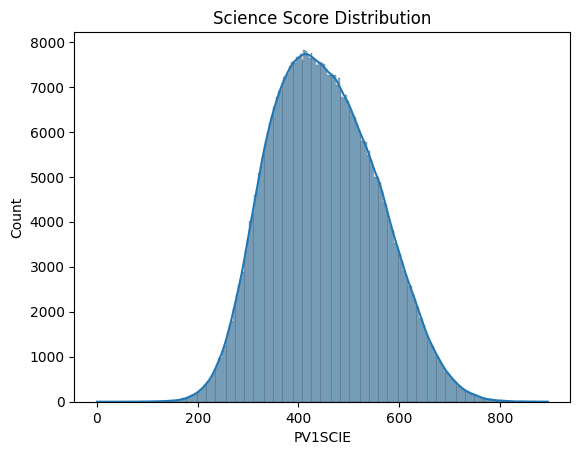

In [7]:
sns.histplot(df_eda["PV1MATH"], kde=True)
plt.title("Math Score Distribution")
plt.show()

sns.histplot(df_eda["PV1READ"], kde=True)
plt.title("Reading Score Distribution")
plt.show()

sns.histplot(df_eda["PV1SCIE"], kde=True)
plt.title("Science Score Distribution")
plt.show()

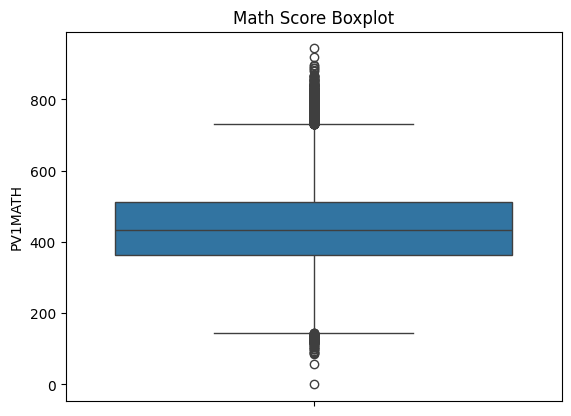

In [8]:
sns.boxplot(y=df_eda["PV1MATH"])
plt.title("Math Score Boxplot")
plt.show()

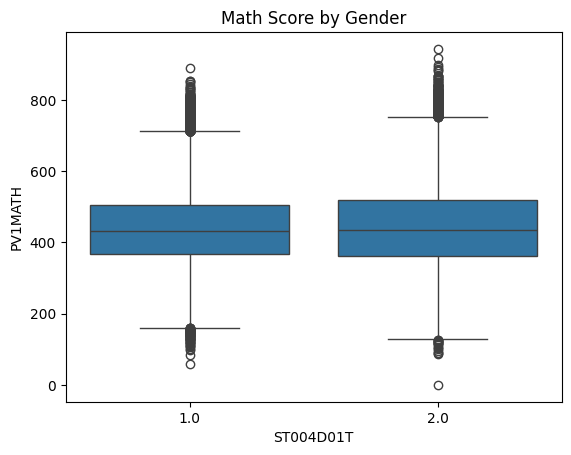

In [9]:
sns.boxplot(x="ST004D01T", y="PV1MATH", data=df_eda)
plt.title("Math Score by Gender")
plt.show()

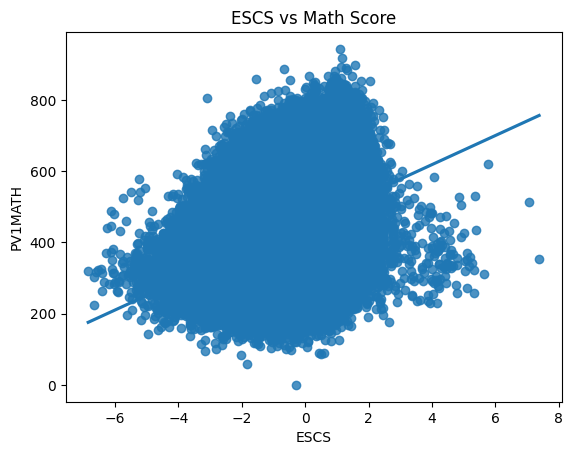

In [13]:
sns.regplot(x="ESCS", y="PV1MATH", data=df_eda)
plt.title("ESCS vs Math Score")
plt.show()

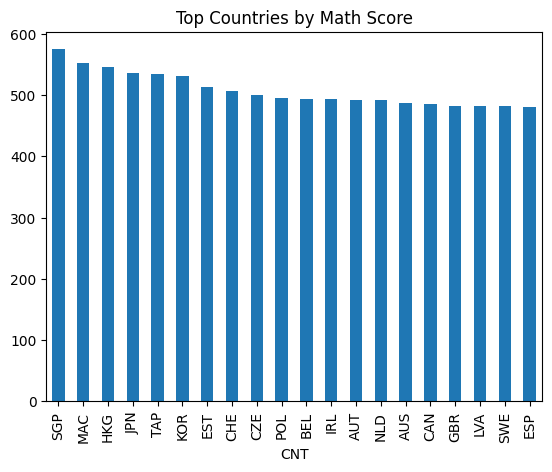

In [14]:
country_avg = df_eda.groupby("CNT")["PV1MATH"].mean().sort_values(ascending=False)

country_avg.head(20).plot(kind="bar")
plt.title("Top Countries by Math Score")
plt.show()

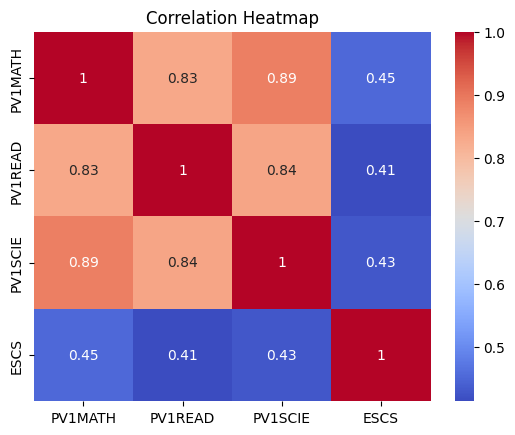

In [15]:
corr = df_eda[["PV1MATH", "PV1READ", "PV1SCIE", "ESCS"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()